In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [20]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
train.head(10)

(8693, 42)


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Alone,RoomService_missing,...,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinNum,Transported,kfold
0,0.0,0.702095,0.0,-0.337025,-0.284274,-0.287317,-0.273736,-0.266098,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,14,0.0,0
1,0.0,-0.333233,0.0,-0.173528,-0.278689,-0.245971,0.209267,-0.227692,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14,1.0,3
2,0.0,2.013510,1.0,-0.272527,1.934922,-0.287317,5.634034,-0.223327,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14,0.0,4
3,0.0,0.287964,0.0,-0.337025,0.511931,0.326250,2.655075,-0.097634,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14,0.0,4
4,0.0,-0.885407,0.0,0.117466,-0.240833,-0.037590,0.223344,-0.264352,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,88,1.0,4
5,0.0,1.047204,0.0,-0.337025,0.015467,-0.287317,-0.017718,-0.266098,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,14,1.0,4
6,0.0,-0.195189,0.0,-0.274027,0.670800,-0.282355,-0.273736,-0.266098,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,180,1.0,2
7,1.0,-0.057145,0.0,-0.337025,-0.284274,-0.287317,-0.273736,-0.266098,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14,1.0,3
8,0.0,0.426008,0.0,-0.337025,0.202882,-0.259202,-0.083702,-0.266098,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,60,1.0,0
9,1.0,-1.023451,0.0,-0.337025,-0.284274,-0.287317,-0.273736,-0.266098,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,88,1.0,4


In [21]:
print(train.info())
print(train.isnull().sum())
print(train.describe())


<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CryoSleep                  8693 non-null   float64
 1   Age                        8693 non-null   float64
 2   VIP                        8693 non-null   float64
 3   RoomService                8693 non-null   float64
 4   FoodCourt                  8693 non-null   float64
 5   ShoppingMall               8693 non-null   float64
 6   Spa                        8693 non-null   float64
 7   VRDeck                     8693 non-null   float64
 8   Alone                      8693 non-null   float64
 9   RoomService_missing        8693 non-null   float64
 10  FoodCourt_missing          8693 non-null   float64
 11  ShoppingMall_missing       8693 non-null   float64
 12  Cabin_missing              8693 non-null   float64
 13  VIP_missing                8693 non-null   float64
 14  Tot

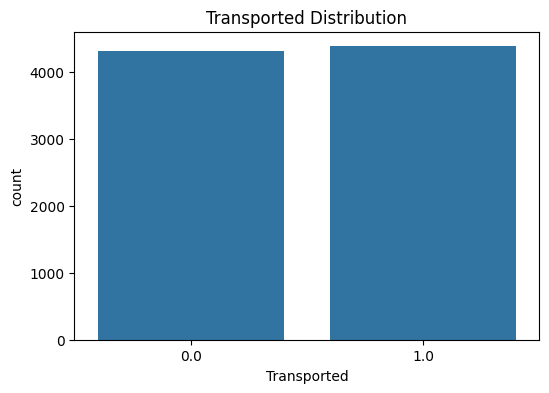

In [22]:

plt.figure(figsize=(6,4))
sns.countplot(x="Transported", data=train)
plt.title("Transported Distribution")
plt.show()


In [23]:
train = train.fillna(0)
test = test.fillna(0)
X = train.drop("Transported", axis=1)
y = train["Transported"]


In [24]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [25]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [26]:
y_pred = model.predict(X_test)


In [27]:
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.7918343875790684

Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.76      0.78       861
         1.0       0.78      0.82      0.80       878

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



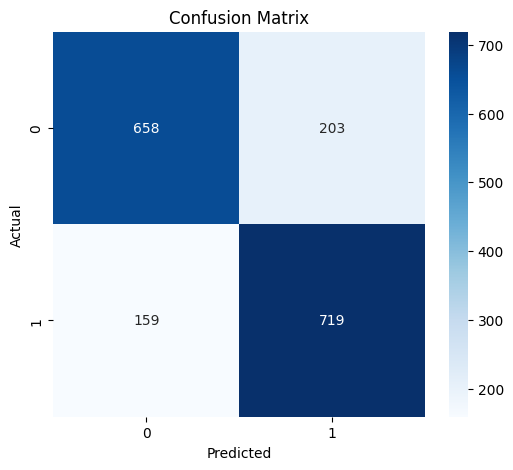

In [28]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Top Important Features
             Feature  Importance
15      TotalExpense    0.163763
6                Spa    0.110391
0          CryoSleep    0.109747
7             VRDeck    0.095967
3        RoomService    0.088010
4          FoodCourt    0.082083
5       ShoppingMall    0.060903
39          CabinNum    0.040450
1                Age    0.037660
17  HomePlanet_Earth    0.025942


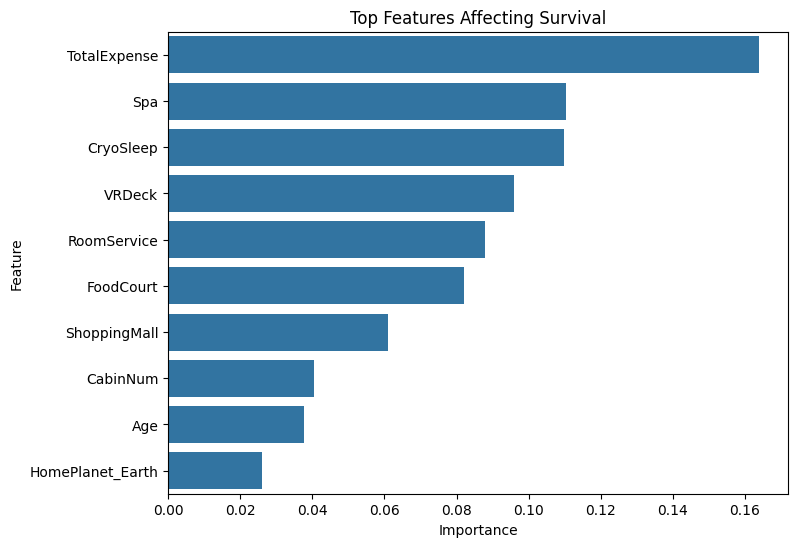

In [29]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features")
print(importance_df.head(10))

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top Features Affecting Survival")
plt.show()

In [30]:
improved_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    random_state=42
)

improved_model.fit(X_train, y_train)

improved_pred = improved_model.predict(X_test)

improved_accuracy = accuracy_score(y_test, improved_pred)

print("\nImproved Model Accuracy:", improved_accuracy)




Improved Model Accuracy: 0.7883841288096607


In [31]:
train_features = X.columns
test = test.drop(columns=["PassengerId"], errors="ignore")
for col in train_features:
    if col not in test.columns:
        test[col] = 0
test = test[train_features]

In [32]:
test_predictions = improved_model.predict(test)
submission = pd.DataFrame({
    "Transported": test_predictions
})
submission.to_csv("submit.csv", index=False)
print("Submission file saved as submit.csv")

Submission file saved as submit.csv
